##**[2주차]실습**
- 아래의 실습1), 실습2), 실습3)에서 **""실습(p.xx)""** 와 같이 표시된 부분을 참고하여, 코드를 완성하시오.
- 실습4)은 시각화 문제로 강의내용에서 배운 것을 응용하여 코드를 완성하시오.


In [ ]:
print("2353881, 최대영")

In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

###**실습1) 퍼셉트론 구현 #2(넘파이 사용) 실습(p. 14)**
**[실습목표]**

- numpy 라이브러리의 함수를 사용하여 perceptron을 구현한다.
- perceptron의 출력은 아래의 수식을 만족한다.

| 입력 형식 | 출력 형식 |
| :--- | :---: |
| 0 0 | 0 |
| 0 1 | 1 |
| 1 0 | 1 |
| 1 1 | 1 |


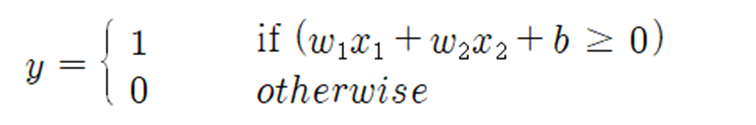

In [1]:
import numpy as np
epsilon = 0.0000001

def perceptron(x1, x2):
  w1, w2, b = 1.0, 1.0, -1.5
  sum = (x1*w1) + (x2*w2) + b # x는 입력값, w는 가중치, b는 편향
  if sum > epsilon:
      return 1 # sum갑이 양수이면, 1반환(AND 연산이 참이면 1반환)
  else :
      return 0 # sum값이 음수이면, 0반환

input1, input2 = [i for i in map(int, input().split())]
perceptron(input1, input2)

1 0


0

###**실습2) 퍼셉트론 학습 알고리즘 구현(넘파이 사용) 실습(p. 17)**
**[실습목표]**

- 퍼셉트론 학습 알고리즘을 구현하고, 학습 과정을 통해 AND 문제를 해결하도록 학습한다.
- 학습 중의 변경된 가중치를 보며 학습 과정을 확인한다.


<출력 형식>
```
epoch= ? ======================
현재 처리 입력= [ 0 0 1] 정답= 0 출력= 0 변경된 가중치= [0.4 0.2 -0.4]
현재 처리 입력= [ 0 1 1] 정답= 0 출력= 0 변경된 가중치= [0.4 0.2 -0.4]
현재 처리 입력= [ 1 0 1] 정답= 0 출력= 0 변경된 가중치= [0.4 0.2 -0.4]
현재 처리 입력= [ 1 1 1] 정답= 1 출력= 1 변경된 가중치= [0.4 0.2 -0.4]
================================
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1
```



In [3]:
import numpy as np

epsilon = 0.0000001		# 부동소수점 오차 방지

X = np.array([			# 훈련 데이터 세트
    [0, 0, 1],			# 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
    [0, 1, 1],			# 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
    [1, 0, 1],			# 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
    [1, 1, 1]			# 맨 끝의 1은 바이어스를 위한 입력 신호 1이다.
])

y = np.array([0, 0, 0, 1])	# 정답을 저장하는 넘파이 행렬
W = np.zeros(len(X[0]))	# 가중치를 저장하는 넘파이 행렬


def step_func(t):		# 퍼셉트론의 활성화 함수
    if t > epsilon:
        return 1
    else:
        return 0

def perceptron_fit(X, Y, epochs=10):	# 퍼셉트론 학습 알고리즘 구현
    global W
    eta = 0.2				# 학습률

    for t in range(epochs):
        print("epoch=", t, "======================")
        for i in range(len(X)):
            predict = step_func(np.dot(X[i], W))
            error = Y[i] - predict # 오차 계산
            W += eta * error * X[i] # 가중치 업데이트

            print("현재 처리 입력=",X[i],"정답=",Y[i],"출력=",predict,"변경된 가중치=", W)
        print("================================")

def perceptron_predict(X, Y):		# 예측
    global W
    for x in X:
         global W
    for x in X:
        print(x[0], x[1], "->", step_func(np.dot(x, W)))

perceptron_fit(X, y, 6)
perceptron_predict(X, y)

epoch= 0 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [0 1 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [1 0 1] 정답= 0 출력= 0 변경된 가중치= [0. 0. 0.]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [0.2 0.2 0.2]
epoch= 1 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 1 변경된 가중치= [0.2 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.  -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 0 변경된 가중치= [ 0.2  0.  -0.2]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [0.4 0.2 0. ]
epoch= 2 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [0.4 0.2 0. ]
현재 처리 입력= [0 1 1] 정답= 0 출력= 1 변경된 가중치= [ 0.4  0.  -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.  -0.4]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
epoch= 3 ======================
현재 처리 입력= [0 0 1] 정답= 0 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
현재 처리 입력= [0 1 1] 정답= 0 출력= 0 변경된 가중치= [ 0.4  0.2 -0.2]
현재 처리 입력= [1 0 1] 정답= 0 출력= 1 변경된 가중치= [ 0.2  0.2 -0.4]
현재 처리 입력= [1 1 1] 정답= 1 출력= 0 변경된 가중치= [ 0.4  0.4 -0.2]
epoch=

###**실습3) sklearn으로 퍼셉트론 실습(p.22)**
**[실습목표]**

- sklearn 라이브러리의 함수를 사용하여 퍼셉트론의 학습을 수행한다.
- AND 연산을 해결하도록 학습을 수행한다.

| 입력 형식 | 출력 형식 |
| :--- | :---: |
| 0 0 | 0 |
| 0 1 | 1 |
| 1 0 | 1 |
| 1 1 | 1 |


In [14]:
from sklearn.linear_model import Perceptron

X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,0,0,1]

# 퍼셉트론 생성
clf = Perceptron(tol = 1e-3, random_state = 0)
# 학습을 수행한다.
clf.fit(X, y)


# 테스트를 수행한다.
input1, input2 = [i for i in map(int, input().split())]
print(int(clf.predict([[input1, input2]])[0]))

1 0
0


### 실습4) 퍼셉트론 시각화
[실습목표]

- matplotlib의 pyplot을 활용하여 퍼셉트론을 시각화 한다.

1.0


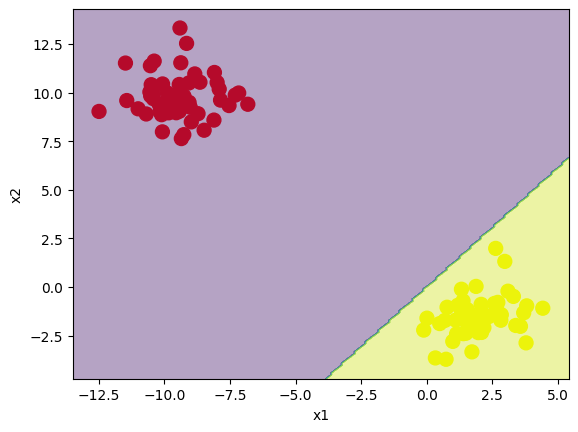

In [20]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
import numpy as np
from sklearn.metrics import accuracy_score

import random

random.seed(32)  # 42 is an arbitrary number, you can use any number

# 퍼셉트론을 생성한다. tol는 종료 조건이다.
clf = Perceptron(tol=1e-3, random_state=0)

# 뭉쳐진 데이터를 만든다. 샘플의 개수는 총 100개, 클러스터의 개수는 2개이다.
X, y = make_blobs(n_samples=100, centers=2)
clf.fit(X,y)

print(accuracy_score(y, clf.predict(X)))

# 데이터를 그래프 위에 표시한다.
plt.scatter(X[:,0], X[:,1], c=y, s=100, cmap='autumn')
plt.xlabel('x1')
plt.ylabel('x2')


# 데이터에서 최소 좌표와 최대 좌표를 계산한다.
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 0.1 간격으로 메쉬 그리드 좌표를 만든다.
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 메쉬 그리드 데이터에 대하여 예측을 한다.
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 컨투어를 그린다.
plt.contourf(xx, yy, Z, alpha=0.4)
plt.show()